<a href="https://colab.research.google.com/github/Rlaslrbs/kaggle/blob/main/kaggle_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



import warnings
warnings.filterwarnings(action='ignore')

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


train data에는 Age, Cabin, Embarked 컬럼에 결측치가 존재한다
test data에는 Age, Fare, Cabin 컬럼에 결측치가 존재한다


<Axes: >

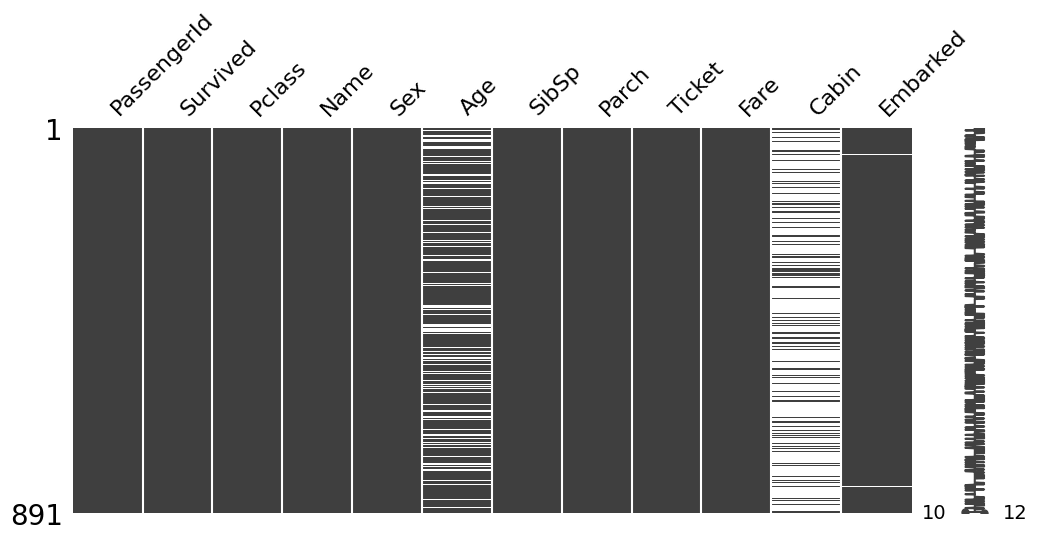

In [ ]:
import missingno as msno
msno.matrix(train, figsize=(12,5))

# EDA

1. Survived


<Axes: ylabel='count'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47581

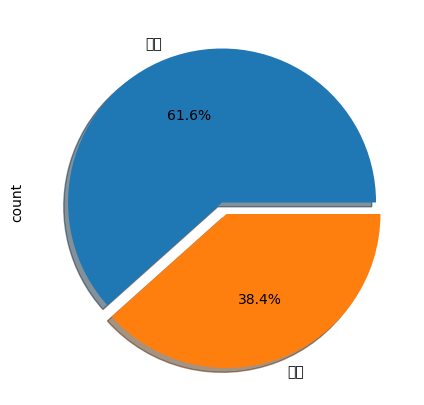

In [ ]:
train["Survived"].value_counts()

plt.figure(figsize=(8, 5))
labels = ['사망', '생존']
train['Survived'].value_counts().plot.pie(explode=[0, 0.08],
                                          shadow=True,
                                          autopct='%1.1f%%',
                                          labels=labels)

2. Sex


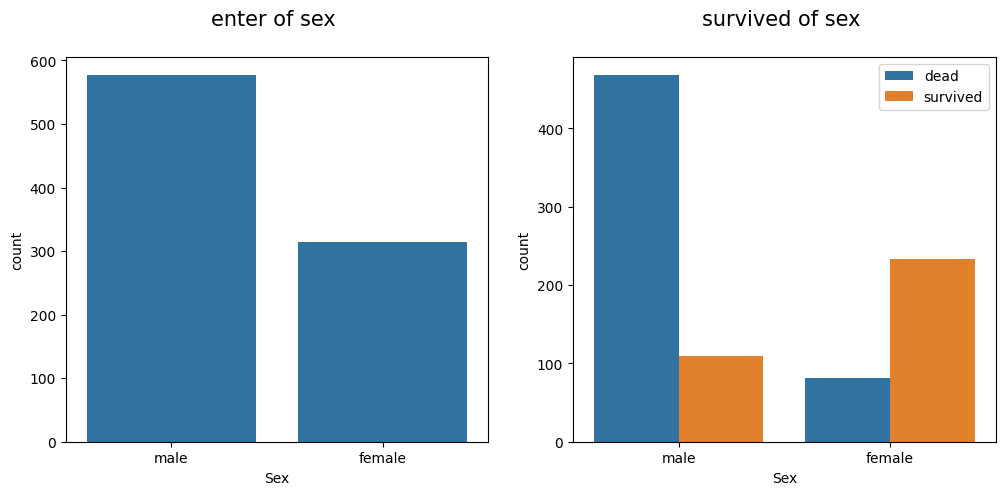

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("enter of sex \n", size=15)
sns.countplot(x="Sex", data=train, ax=axes[0])

axes[1].set_title("survived of sex \n", size=15)
sns.countplot(x="Sex", hue="Survived", data=train, ax=axes[1])
axes[1].legend(labels = ['dead', 'survived'])

남성의 탑승자 수가 더 많지만 여성의 생존자 수가 더 많다

,Survived
Sex,
female,0.742038
male,0.188908


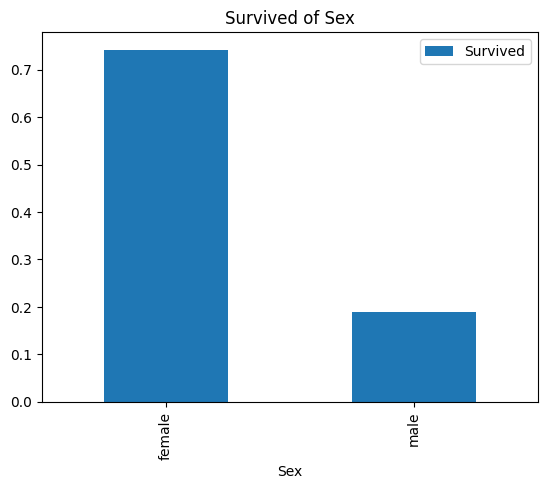

In [ ]:
sur = train[['Sex', 'Survived']].groupby('Sex').mean().plot.bar()
sur.set_title('Survived of Sex')
train[['Sex', 'Survived']].groupby('Sex').mean()

여성의 생존률은 약 74.2%, 남성의 생존률은 약 18.9%로 여성의 생존률이 압도적으로 높은 것이 확인된다.

**3. Pclass**

In [ ]:
train[['Pclass', 'Survived']].groupby('Pclass').mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


3등석 탑승객들이 많이 사망한 것으로 보인다.

**4. Age**


In [ ]:
train['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: xlabel='Age', ylabel='Density'>

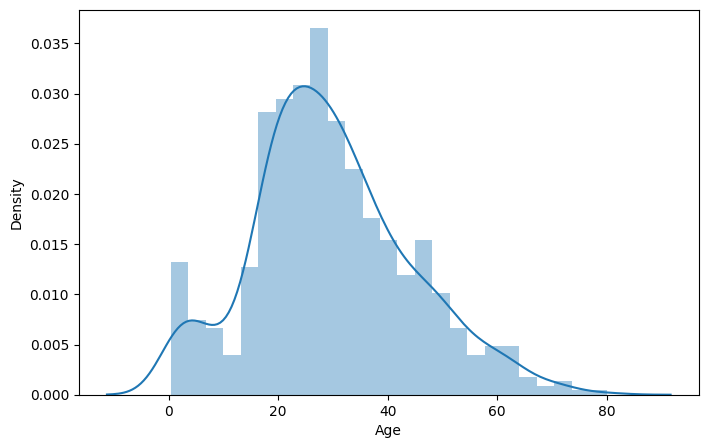

In [ ]:
plt.figure(figsize=(8,5))
sns.distplot(train['Age'], bins=25)

탑승객들의 나이는 주로 20~40세에 분포중


<Axes: xlabel='Age', ylabel='Density'>

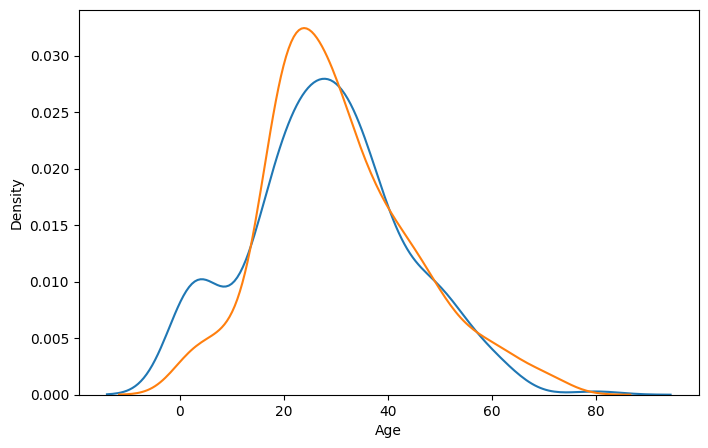

In [ ]:
sur = train[train['Survived'] == 1]
dead = train[train['Survived'] == 0]

plt.figure(figsize=(8,5))
sns.distplot(sur['Age'], bins=25, hist=False)
sns.distplot(dead['Age'], bins=25, hist=False)

어린나이의 탑승객들의 생존률이 비교적 높고 20~30세의 생존률은 비교적 낮은 것으로 보인다.

5. SibSp, Parch

In [ ]:
train[['SibSp', 'Survived']].groupby(['SibSp']).mean()

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [ ]:
train[['Parch', 'Survived']].groupby(['Parch']).mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


혼자 탑승한 사람보다 3명, 4명의 SibSp와 탑승한 탑승객들의 사망률이 가장 높다.
부모, 자녀 없이 혼자 탑승한 사람의 사망률이 가장 높다.

**6. Embarked**

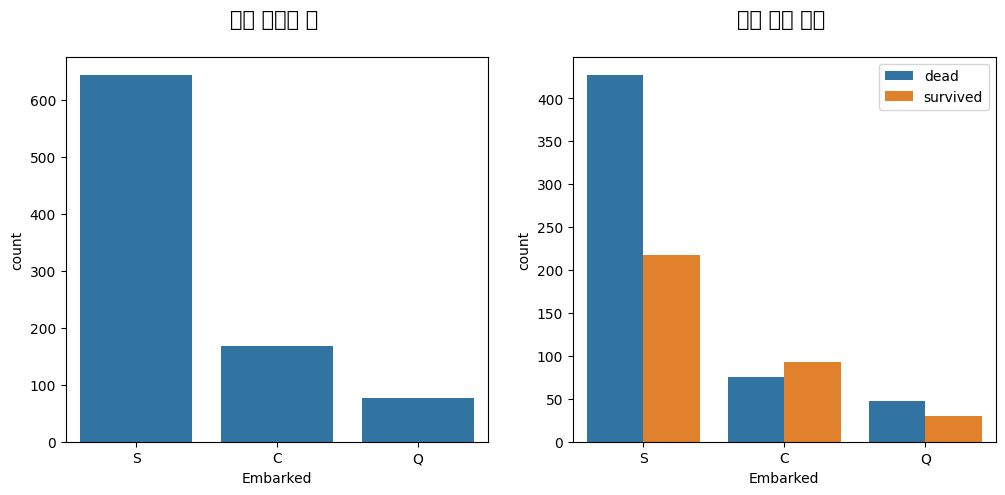

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("성별 탑승자 수 \n", size=15)
sns.countplot(x="Embarked", data=train, ax=axes[0])

axes[1].set_title("성별 생존 여부 \n", size=15)
sns.countplot(x="Embarked", hue="Survived", data=train, ax=axes[1])
axes[1].legend(labels = ['dead', 'survived'])

In [ ]:
train[['Embarked', 'Survived']].groupby(['Embarked']).mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


s항구의 사망률이 가장 높다.

<Axes: >

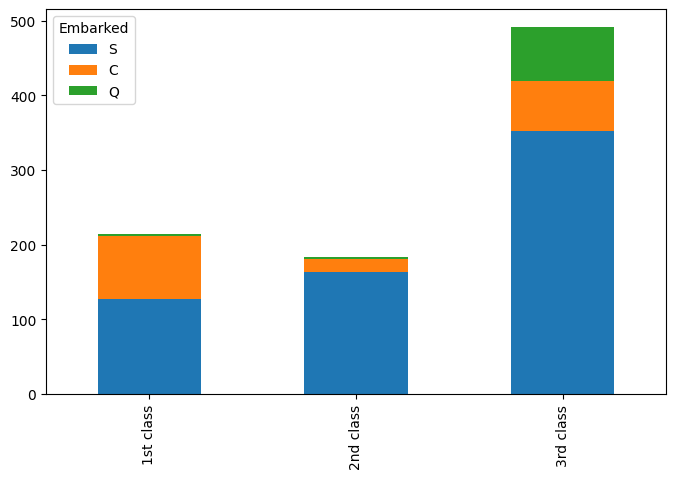

In [ ]:
pc1 = train[train['Pclass'] == 1]['Embarked'].value_counts()
pc2 = train[train['Pclass'] == 2]['Embarked'].value_counts()
pc3 = train[train['Pclass'] == 3]['Embarked'].value_counts()
pc = pd.DataFrame([pc1, pc2, pc3])
pc.index = ['1st class', '2nd class', '3rd class']

fig, ax = plt.subplots(figsize=(8, 5))
pc.plot(kind='bar', stacked=True, ax=ax)

3등석에 S항구 탑승객이 많은 것을 확인할 수 있다.
위에서 3등석의 사망률이 가장 높았듣이 3등석에 S항구 탑승객들이 많아서 S항구 탑승객들의 사망률이 높은 것으로 보인다.

**7.Fare**

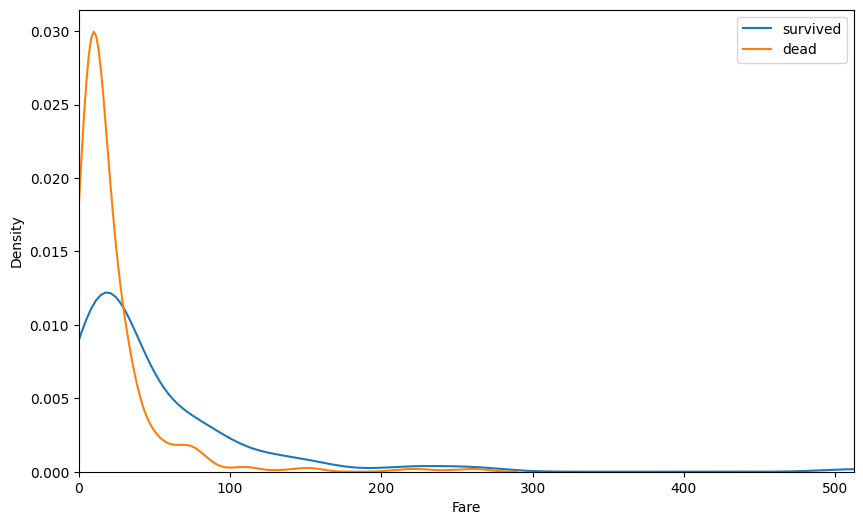

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# 분포 확인
sns.kdeplot(train[train['Survived']==1]['Fare'], ax=ax)
sns.kdeplot(train[train['Survived']==0]['Fare'], ax=ax)

# 축 범위
ax.set(xlim=(0, train['Fare'].max()))
ax.legend(['survived', 'dead'])

plt.show()

탑승금액이 적은 쪽은 사망률이 높다
위에서 보았듯이 탑승 클래스. 탑승 금액에 따라 생존 여부에 영향을 끼친다.

#  Feature Engineering & modeling


In [3]:
train.drop(['Name', 'Ticket', 'Cabin'], axis=1).corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [4]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
data_list = [train, test]

1. sex

In [6]:
for data in data_list:
  data['Sex'] = data['Sex'].astype('category').cat.codes

train['Sex'].head()

,Sex
0,1
1,0
2,0
3,0
4,1


male(남성)과 female(여성)을 1과 0으로 변경

2. Age

In [7]:
sex_mean = train.groupby('Sex')['Age'].mean()
sex_mean

,Age
Sex,
0,27.915709
1,30.726645


위에서 Age 칼럼에 177개의 결측치가 존재했으니, 이 결측치에 대해서 여성에겐 여성 나이의 평균, 남성에겐 남성 나이의 평균으로 채워준다.


In [8]:
for data in data_list:
    data.loc[(data['Sex'] == 0) & (data['Age'].isnull()), 'Age'] = sex_mean[0]
    data.loc[(data['Sex'] == 1) & (data['Age'].isnull()), 'Age'] = sex_mean[1]

train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
train['AgeRange'] = pd.cut(train['Age'], 5)
train[['AgeRange', 'Survived']].groupby(['AgeRange']).mean()

,Survived
AgeRange,
"(0.34, 16.336]",0.550000
"(16.336, 32.252]",0.344168
"(32.252, 48.168]",0.404255
"(48.168, 64.084]",0.434783
"(64.084, 80.0]",0.090909


남자, 여자는 0,1로 극명하게 나뉘지만, 나이의 경우 20과 30의 차이가 10이라고 해서 극명하게 나뉘는 값이 아니다.  이를 전체적인 범주에 맞게 낮춰주기 위해 카테고리화를 한다.


In [10]:
for data in data_list:
    data.loc[ data['Age'] <= 16, 'Age'] = 0
    data.loc[(data['Age'] > 16) & (data['Age'] <= 32), 'Age'] = 1
    data.loc[(data['Age'] > 32) & (data['Age'] <= 48), 'Age'] = 2
    data.loc[(data['Age'] > 48) & (data['Age'] <= 64), 'Age'] = 3
    data.loc[ data['Age'] > 64, 'Age'] = 4
train.drop('AgeRange', inplace=True, axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,2.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,2.0,0,0,373450,8.0500,NaN,S


3. Name


탑승객들 이름 앞을 추출해보면 Mr, Mrs, Miss등이 붙어있는데 이는 생존자 예측에 크게 도움이 되지 않으므로 간소화 한다.


In [11]:
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Mr, Miss, Mrs, Master가 가장 많이 존재하고, 나머지는 적게 존재하므로 복잡도를 증가시키지 않기 위해 나머지는 'Other'로 통일시킨다.

In [12]:
for data in data_list:
    data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    data['Title'] = data['Title'].replace(['Dr', 'Rev', 'Mlle', 'Major', 'Col', 'Countess',
                                        'Capt', 'Ms', 'Sir', 'Lady', 'Mme', 'Don', 'Jonkheer'], 'Other')
    # -> 범주형 -> 수치형
    data['Title_name'] = data['Title'].astype('category').cat.codes

In [13]:
train[['Title', 'Survived']].groupby(['Title']).mean()

,Survived
Title,
Master,0.575000
Miss,0.697802
Mr,0.156673
Mrs,0.792000
Other,0.444444


In [14]:
# 불필요한 데이터 지우기
train.drop(['Name', 'Title'], axis=1, inplace = True)
test.drop(['Name', 'Title'], axis=1, inplace = True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_name
0,1,0,3,1,1.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,0,2.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,0,2.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,1,2.0,0,0,373450,8.0500,NaN,S,2


4. SibSp + Parch

In [15]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

In [16]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,1,0,A/5 21171,7.2500,NaN,S,2,2
1,2,1,1,0,2.0,1,0,PC 17599,71.2833,C85,C,3,2
2,3,1,3,0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,0,2.0,1,0,113803,53.1000,C123,S,3,2
4,5,0,3,1,2.0,0,0,373450,8.0500,NaN,S,2,1


In [17]:
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,892,3,1,2.0,0,0,330911,7.8292,NaN,Q,3,1
1,893,3,0,2.0,1,0,363272,7.0000,NaN,S,4,2
2,894,2,1,3.0,0,0,240276,9.6875,NaN,Q,3,1
3,895,3,1,1.0,0,0,315154,8.6625,NaN,S,3,1
4,896,3,0,1.0,1,1,3101298,12.2875,NaN,S,4,3


<Axes: xlabel='FamilySize', ylabel='count'>

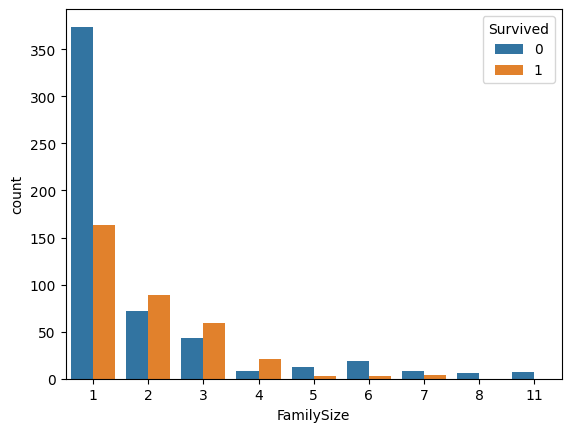

In [19]:

sns.countplot(data=train, x='FamilySize', hue='Survived')

In [22]:
pd.pivot_table(train, index='FamilySize', values='Survived')

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


In [23]:
# 컬럼제거

drop_list = ['SibSp', 'Parch']
for data in data_list:
  data.drop(drop_list, inplace=True, axis=1)

In [24]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,A/5 21171,7.2500,NaN,S,2,2
1,2,1,1,0,2.0,PC 17599,71.2833,C85,C,3,2
2,3,1,3,0,1.0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,0,2.0,113803,53.1000,C123,S,3,2
4,5,0,3,1,2.0,373450,8.0500,NaN,S,2,1


5. Embarked

<Axes: xlabel='Embarked', ylabel='count'>

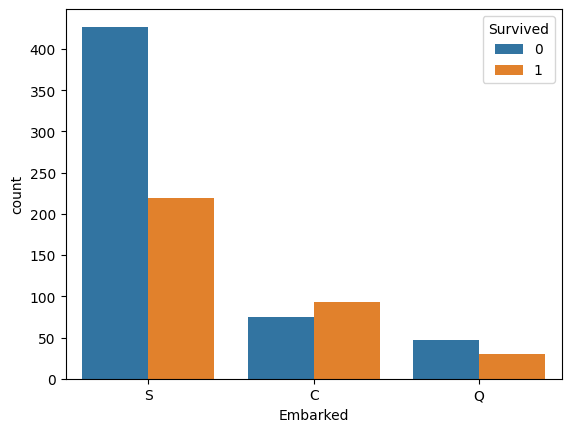

In [26]:
for data in data_list:
  data['Embarked'] = data['Embarked'].fillna('S')

sns.countplot(data=train, x='Embarked', hue='Survived')

C에서 탑승한 사람들이 상대적으로 많이 살아남은 것으로 보인다.

In [27]:
em_mapping = {'S' : 0, 'C' :1, 'Q':2}
for data in data_list:
  data['Embarked'] = data['Embarked'].map(em_mapping)

6. Cabin


In [29]:
train['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [30]:
for data in data_list:
  data['Cabin'] = data['Cabin'].fillna('N')
  data['Cabin'] = data['Cabin'].apply(lambda x:x[0])
  data['Cabin'] = data['Cabin'].astype('category').cat.codes


In [32]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,A/5 21171,7.2500,7,0,2,2
1,2,1,1,0,2.0,PC 17599,71.2833,2,1,3,2
2,3,1,3,0,1.0,STON/O2. 3101282,7.9250,7,0,1,1
3,4,1,1,0,2.0,113803,53.1000,2,0,3,2
4,5,0,3,1,2.0,373450,8.0500,7,0,2,1


만약 Cabin 컬럼에 ['A1', 'B3', 'C2', 'B1', 'A2'] 같은 데이터가 있었다면:

첫 번째 처리 (x[0]):
['A', 'B', 'C', 'B', 'A']

두 번째 처리 (astype('category').cat.codes):
['A' -> 0, 'B' -> 1, 'C' -> 2]
즉, ['0', '1', '2', '1', '0']로 변환됩니다.

이렇게 변환된 수치형 값은 머신러닝 모델에서 쉽게 처리할 수 있다.

7.Fare

In [33]:
for data in data_list:
  data['Farerange'] = pd.cut(data['Fare'],4)

train[['Farerange', 'Survived']].groupby(['Farerange']).mean()

,Survived
Farerange,
"(-0.512, 128.082]",0.368113
"(128.082, 256.165]",0.724138
"(256.165, 384.247]",0.666667
"(384.247, 512.329]",1.000000


In [34]:
for data in data_list:
    data.loc[data['Fare'] <= 128, 'Fare'] = 0
    data.loc[(data['Fare'] > 128) & (data['Fare'] <= 256), 'Fare'] = 1
    data.loc[(data['Fare'] > 256) & (data['Fare'] <= 384), 'Fare'] = 2
    data.loc[data['Fare'] > 384, 'Fare'] = 3

train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize,Farerange
0,1,0,3,1,1.0,A/5 21171,0.0,7,0,2,2,"(-0.512, 128.082]"
1,2,1,1,0,2.0,PC 17599,0.0,2,1,3,2,"(-0.512, 128.082]"
2,3,1,3,0,1.0,STON/O2. 3101282,0.0,7,0,1,1,"(-0.512, 128.082]"
3,4,1,1,0,2.0,113803,0.0,2,0,3,2,"(-0.512, 128.082]"
4,5,0,3,1,2.0,373450,0.0,7,0,2,1,"(-0.512, 128.082]"


In [36]:
# 컬럼 지우기
for data in data_list:
    data.drop('Farerange',axis=1, inplace=True)

8. Drop Data

In [37]:
drop_list = ['PassengerId', 'Ticket']
for data in data_list:
    data.drop(drop_list, inplace=True, axis=1)

for data in data_list:
    data.drop('Cabin', inplace=True, axis=1)

9. test data 결측치

In [38]:
test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
Fare,1
Embarked,0
Title_name,0
FamilySize,0


In [39]:
test[test['Fare'].isnull()] = test['Fare'].mean()

In [40]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title_name,FamilySize
0,0,3,1,1.0,0.0,0,2,2
1,1,1,0,2.0,0.0,1,3,2
2,1,3,0,1.0,0.0,0,1,1
3,1,1,0,2.0,0.0,0,3,2
4,0,3,1,2.0,0.0,0,2,1


In [41]:
test.head()

,Pclass,Sex,Age,Fare,Embarked,Title_name,FamilySize
0,3.0,1.0,2.0,0.0,2.0,3.0,1.0
1,3.0,0.0,2.0,0.0,0.0,4.0,2.0
2,2.0,1.0,3.0,0.0,2.0,3.0,1.0
3,3.0,1.0,1.0,0.0,0.0,3.0,1.0
4,3.0,0.0,1.0,0.0,0.0,4.0,3.0


In [42]:
train.corr()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title_name,FamilySize
Survived,1.000000,-0.338481,-0.543351,-0.043800,0.147466,0.106811,-0.052471,0.016639
Pclass,-0.338481,1.000000,0.131900,-0.358769,-0.298580,0.045702,-0.195910,0.065997
Sex,-0.543351,0.131900,1.000000,0.070220,-0.114771,-0.116569,0.040484,-0.200988
Age,-0.043800,-0.358769,0.070220,1.000000,0.063220,-0.051334,0.427999,-0.217063
Fare,0.147466,-0.298580,-0.114771,0.063220,1.000000,0.047596,-0.044644,0.098769
Embarked,0.106811,0.045702,-0.116569,-0.051334,0.047596,1.000000,-0.081928,-0.080281
Title_name,-0.052471,-0.195910,0.040484,0.427999,-0.044644,-0.081928,1.000000,-0.207530
FamilySize,0.016639,0.065997,-0.200988,-0.217063,0.098769,-0.080281,-0.207530,1.000000


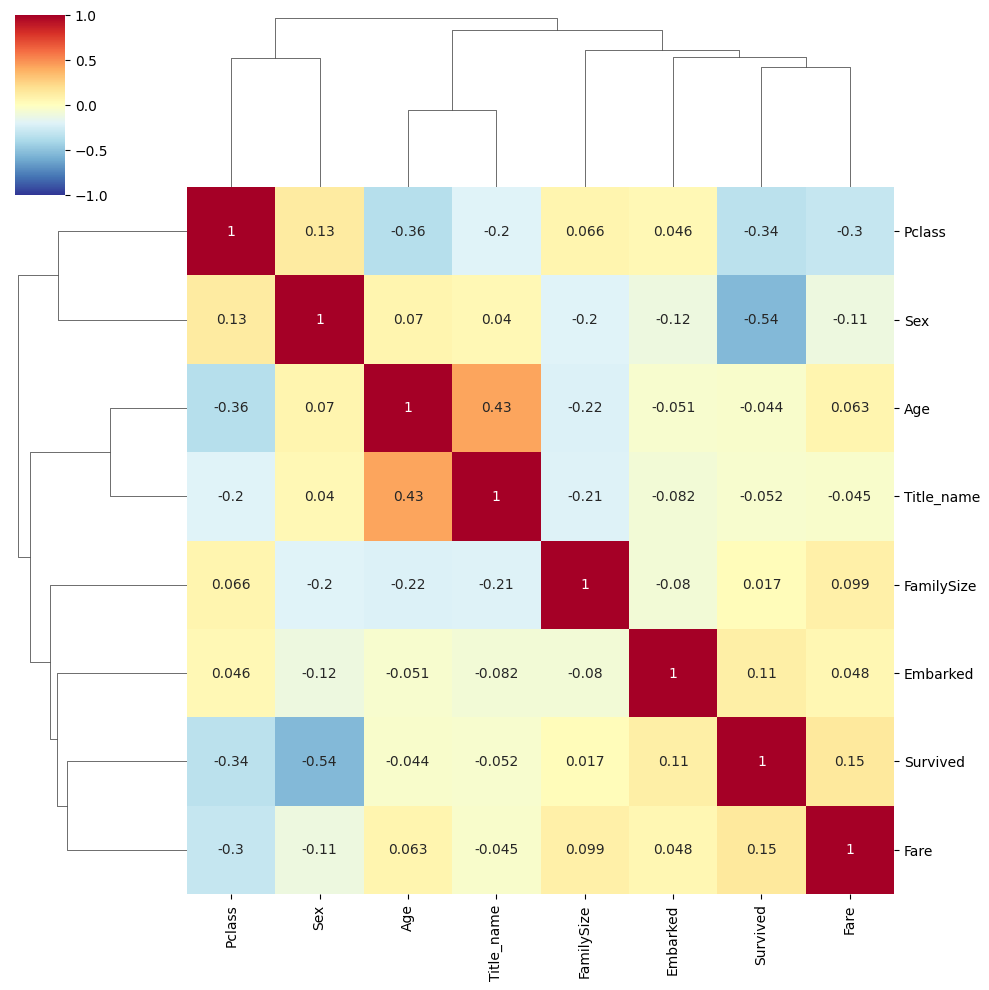

In [44]:
df = train.corr()


sns.clustermap(df,
               annot=True,  # 실제 값 화면에 나타내기
               cmap = 'RdYlBu_r', # Red, Yellow, Blue 색상으로 표시
               vmin = -1, vmax = 1, #컬러차트 -1~1 범위로 표시
               )

**모델링**

In [45]:
train_input = train.drop('Survived', axis=1).values
train_target = train['Survived'].values
print(train_input.shape, train_target.shape)  #(891, 7) (891,)

(891, 7) (891,)


In [46]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

1. KNN


In [47]:
model = KNeighborsClassifier()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.8392253809666388 0.8024794425961963


2. Dicision Tree

In [48]:
model = DecisionTreeClassifier()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.872335203366059 0.8024919967359236


3. Random Forest

In [49]:
model = RandomForestClassifier()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.872335203366059 0.8047580189567508


4. GradientBoosting

In [50]:
model = GradientBoostingClassifier()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.8555009691602187 0.8204632477559475


5. HistGradientBoosting

In [51]:
model = HistGradientBoostingClassifier()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.8597093307278945 0.8126043562864854


6.Naive Bayes

In [52]:
model = GaussianNB()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.8117284145169169 0.812560416797439


7. Support Vector Machine

In [53]:
model = SVC()
score = cross_validate(model, train_input, train_target,
                      return_train_score=True, n_jobs=-1,
                      cv = StratifiedKFold())
print(np.mean(score['train_score']), np.mean(score['test_score']))

0.8366992609168413 0.8349946644906158


최종 모델 : KNN

In [55]:
submission = pd.read_csv('gender_submission.csv')

In [56]:
model = KNeighborsClassifier()
model.fit(train_input, train_target)
test_input = test.values
pred = model.predict(test)

submission['Survived'] = pred
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [57]:
submission.to_csv("submission_result.csv", index=False)